In [14]:
import sys
from pathlib import Path

# 1. Get the absolute path to your home directory
home_dir = Path.home()
# print(home_dir)
# 2. Define the path to your library folder (e.g., "my_libs")
library_path = home_dir /"/Users/rindhujajohnson/Documents/GitHub/modeling-solar-energetic-particle-acceleration-and-transport-in-CME-driven-shokes-using-MHD"

# 3. Append to sys.path if it isn't already there
if str(library_path) not in sys.path:
    sys.path.insert(0, str(library_path))

print("Library path added to sys.path:", library_path)

Library path added to sys.path: /Users/rindhujajohnson/Documents/GitHub/modeling-solar-energetic-particle-acceleration-and-transport-in-CME-driven-shokes-using-MHD


In [15]:
# !pip install torch

This notebook demonstrates an end-to-end research workflow linking macro-scale Magnetohydrodynamic (MHD) shock profiles, kinetic particle transport equations, and deep learning spatial-temporal telemetry imputation.

In [16]:
import os
import sys
import numpy as np
import torch
import matplotlib.pyplot as plt

from core.mhd_shock import CMEShockGenerator
from core.transport_solver import FocusedTransportSolver
from ml_gap_filling.data_degrader import SpacecraftDataDegrader
from ml_gap_filling.reconstructor import PADReconstructionNet, train_reconstructor, impute_corrupted_data


## Step 1: Initialize the Space Environment via MHD Profiles

We instantiate a moving CME shock front using Rankine-Hugoniot jump modeling.

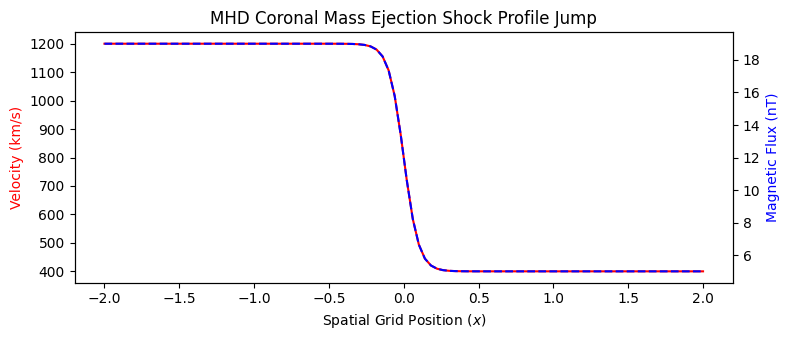

In [17]:

# Define spatial grid (Heliocentric distance axes) and pitch-angle configuration
x_grid = np.linspace(-2.0, 2.0, 100)
mu_grid = np.linspace(-1.0, 1.0, 64)

# Generate CME Shock boundary layer metrics
shock_engine = CMEShockGenerator(shock_position=0.0, shock_width=0.1, compression_ratio=3.8)
v_sw = shock_engine.compute_plasma_speed_profile(x_grid)
b_field = shock_engine.compute_magnetic_field_profile(x_grid)
dv_dx = shock_engine.compute_adiabatic_divergence(x_grid, v_sw)

# Plotting the physical space environment background
fig, ax1 = plt.subplots(figsize=(8, 3.5), dpi=100)
ax2 = ax1.twinx()
ax1.plot(x_grid, v_sw, 'r-', label="Solar Wind Speed ($V_{sw}$)")
ax2.plot(x_grid, b_field, 'b--', label="Magnetic Field ($B$)")
ax1.set_xlabel("Spatial Grid Position ($x$)")
ax1.set_ylabel("Velocity (km/s)", color='r')
ax2.set_ylabel("Magnetic Flux (nT)", color='b')
plt.title("MHD Coronal Mass Ejection Shock Profile Jump")
plt.tight_layout()
plt.show()


## Step 2: Ingest Shock Parameters into the Particle Transport Solver
We construct a pristine seed particle distribution and let it scatter through the non-uniform magnetic environment.

<>:20: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:22: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:20: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:22: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/var/folders/nh/yrp4xfj533s7rq4ms7rg6_k00000gn/T/ipykernel_9827/3008862254.py:20: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.colorbar(label='Particle Phase Space Density $f(x, \mu)$')
/var/folders/nh/yrp4xfj533s7rq4ms7rg6_k00000gn/T/ipykernel_9827/3008862254.py:22: SyntaxWa

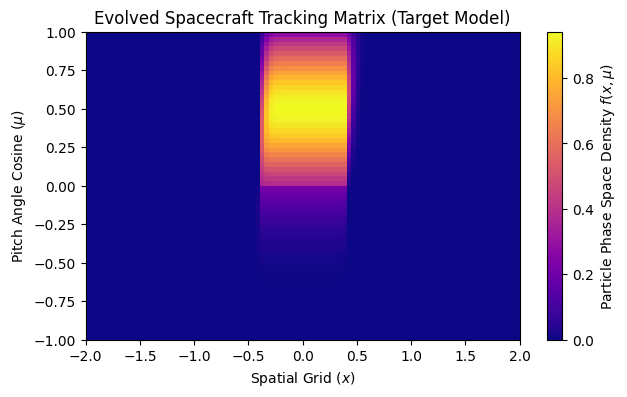

In [18]:
# Base spatial seed particle distribution
f_pristine = np.zeros((len(x_grid), len(mu_grid)))
f_pristine[40:60, :] = np.exp(-((mu_grid[None, :] - 0.5)**2) / 0.2)  # Anisotropic forward beam

# Initialize transport engine with scattering constraints scaling with local B-field variations
mean_free_path_scale = 0.05
solver = FocusedTransportSolver(x_grid=x_grid, mu_grid=mu_grid, v=0.2, D0=mean_free_path_scale)

# Perform forward integration over discrete time-steps
num_steps = 50
dt = 0.005
f_evolved = np.copy(f_pristine)

for _ in range(num_steps):
    f_evolved = solver.step(f_evolved, dt=dt)

# Visualize Evolved Pitch-Angle Distribution matrix
plt.figure(figsize=(7, 4), dpi=100)
plt.imshow(f_evolved.T, extent=[-2, 2, -1, 1], origin='lower', aspect='auto', cmap='plasma')
plt.colorbar(label='Particle Phase Space Density $f(x, \mu)$')
plt.xlabel("Spatial Grid ($x$)")
plt.ylabel("Pitch Angle Cosine ($\mu$)")
plt.title("Evolved Spacecraft Tracking Matrix (Target Model)")
plt.show()




## Step 3: Simulate Telemetry Drops and Mask Instrument Blindspots
We intentionally degrade the crisp data matrix to mirror multi-mission sensor dropouts.

<>:9: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:9: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/var/folders/nh/yrp4xfj533s7rq4ms7rg6_k00000gn/T/ipykernel_9827/1012602543.py:9: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.ylabel("Pitch Angle Cosine ($\mu$)")


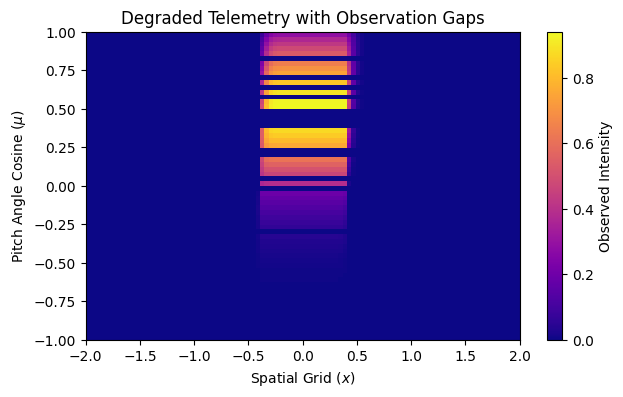

In [19]:
degrader = SpacecraftDataDegrader(random_state=42)
f_corrupted, observation_mask = degrader.inject_pitch_angle_gaps(f_evolved, mask_fraction=0.25, gap_type='patch')

# Visualize Gapped Telemetry Array
plt.figure(figsize=(7, 4), dpi=100)
plt.imshow(f_corrupted.T, extent=[-2, 2, -1, 1], origin='lower', aspect='auto', cmap='plasma')
plt.colorbar(label='Observed Intensity')
plt.xlabel("Spatial Grid ($x$)")
plt.ylabel("Pitch Angle Cosine ($\mu$)")
plt.title("Degraded Telemetry with Observation Gaps")
plt.show()


## Step 4: Run Deep Learning Imputation 
We optimize our physics-inspired network over the unmasked validation matrix boundaries.

In [20]:
# Configure neural pipeline dimensions matching our x-bin angular grid
reconstructor_net = PADReconstructionNet(input_dim=len(mu_grid))

print(">>> Commencing Masked-MSE Structural Gap Reconstruction...")
train_reconstructor(
    model=reconstructor_net, 
    corrupted_data=f_corrupted, 
    target_data=f_evolved, 
    mask=observation_mask, 
    epochs=300, 
    lr=2e-3
)

# Extract optimized continuum profiles with selective imputation
f_reconstructed = impute_corrupted_data(reconstructor_net, f_corrupted, observation_mask)

>>> Commencing Masked-MSE Structural Gap Reconstruction...
Epoch 50/300 - Loss: 0.006898
Epoch 100/300 - Loss: 0.006883
Epoch 150/300 - Loss: 0.006879
Epoch 200/300 - Loss: 0.006873
Epoch 250/300 - Loss: 0.006865
Epoch 300/300 - Loss: 0.006858
Training complete! Final loss: 0.006858


## Step 5: Validate Imputation Profile Against Ground Truth
We plot a slice of our pitch-angle profile across the shock zone to demonstrate recovery.

<>:7: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:7: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/var/folders/nh/yrp4xfj533s7rq4ms7rg6_k00000gn/T/ipykernel_9827/598354834.py:7: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.xlabel("Pitch-Angle Cosine ($\mu$)")


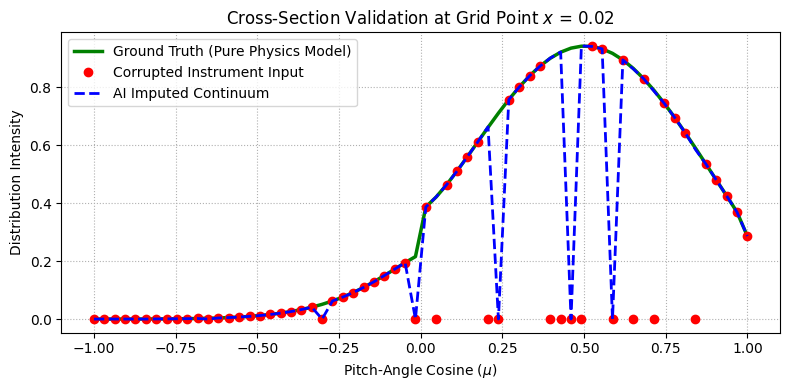

In [21]:
test_slice_idx = 50  # Mid-grid location near shock intersection zone

plt.figure(figsize=(8, 4), dpi=100)
plt.plot(mu_grid, f_evolved[test_slice_idx, :], 'g-', lw=2.5, label='Ground Truth (Pure Physics Model)')
plt.plot(mu_grid, f_corrupted[test_slice_idx, :], 'ro', markersize=6, label='Corrupted Instrument Input')
plt.plot(mu_grid, f_reconstructed[test_slice_idx, :], 'b--', lw=2, label='AI Imputed Continuum')
plt.xlabel("Pitch-Angle Cosine ($\mu$)")
plt.ylabel("Distribution Intensity")
plt.title(def_title := f"Cross-Section Validation at Grid Point $x$ = {x_grid[test_slice_idx]:.2f}")
plt.legend()
plt.grid(True, linestyle=':')
plt.tight_layout()
plt.show()

In [22]:
# Calculate Performance Metrics - ONLY on MISSING positions
missing_mask = ~observation_mask  # True where data is missing (False in degrader mask)

# Compute RMSE only where data was imputed
reconstruction_error = np.mean((f_evolved[missing_mask] - f_reconstructed[missing_mask]) ** 2)
print(f"\n>>> Computational pipeline execution verified successfully.")
print(f">>> Root Mean Squared Error (RMSE) across imputed positions: {np.sqrt(reconstruction_error):.5f}")

# Optional: Also show error on non-missing positions (should be near-zero)
available_mask = observation_mask  # True where data is available
error_available = np.mean((f_evolved[available_mask] - f_reconstructed[available_mask]) ** 2)
print(f">>> Error on available positions (should be near-zero): {np.sqrt(error_available):.5f}")


>>> Computational pipeline execution verified successfully.
>>> Root Mean Squared Error (RMSE) across imputed positions: 0.16562
>>> Error on available positions (should be near-zero): 0.00000


## Step 3b: Simulate Telemetry Drops and Mask Instrument Blindspots with gap_type = `random`
We intentionally degrade the crisp data matrix to mirror multi-mission sensor dropouts.

<>:9: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:9: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/var/folders/nh/yrp4xfj533s7rq4ms7rg6_k00000gn/T/ipykernel_9827/3200088610.py:9: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.ylabel("Pitch Angle Cosine ($\mu$)")


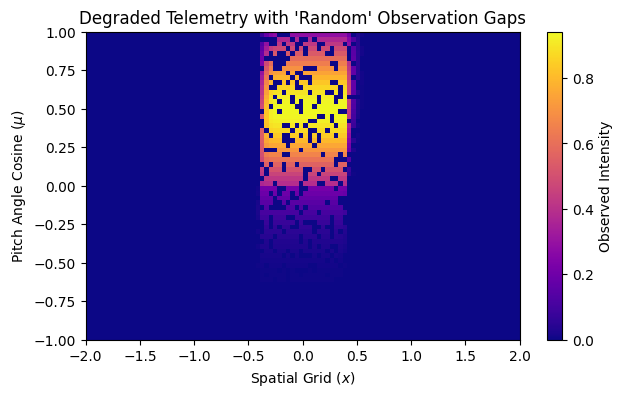

In [23]:
degrader = SpacecraftDataDegrader(random_state=42)
f_corrupted, observation_mask = degrader.inject_pitch_angle_gaps(f_evolved, mask_fraction=0.25, gap_type='random')

# Visualize Gapped Telemetry Array
plt.figure(figsize=(7, 4), dpi=100)
plt.imshow(f_corrupted.T, extent=[-2, 2, -1, 1], origin='lower', aspect='auto', cmap='plasma')
plt.colorbar(label='Observed Intensity')
plt.xlabel("Spatial Grid ($x$)")
plt.ylabel("Pitch Angle Cosine ($\mu$)")
plt.title("Degraded Telemetry with 'Random' Observation Gaps")
plt.show()


## Step 4b: Run Deep Learning Imputation 
We optimize our physics-inspired network over the unmasked validation matrix boundaries.

In [24]:
# Configure neural pipeline dimensions matching our x-bin angular grid
reconstructor_net = PADReconstructionNet(input_dim=len(mu_grid))

print(">>> Commencing Masked-MSE Structural Gap Reconstruction...")
train_reconstructor(
    model=reconstructor_net, 
    corrupted_data=f_corrupted, 
    target_data=f_evolved, 
    mask=observation_mask, 
    epochs=300, 
    lr=2e-3
)

# Extract optimized continuum profiles with selective imputation
f_reconstructed = impute_corrupted_data(reconstructor_net, f_corrupted, observation_mask)

>>> Commencing Masked-MSE Structural Gap Reconstruction...
Epoch 50/300 - Loss: 0.001082
Epoch 100/300 - Loss: 0.001024
Epoch 150/300 - Loss: 0.001013
Epoch 200/300 - Loss: 0.001001
Epoch 250/300 - Loss: 0.000998
Epoch 300/300 - Loss: 0.000997
Training complete! Final loss: 0.000997


## Step 5b: Validate Imputation Profile Against Ground Truth
We plot a slice of our pitch-angle profile across the shock zone to demonstrate recovery.

<>:7: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:7: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/var/folders/nh/yrp4xfj533s7rq4ms7rg6_k00000gn/T/ipykernel_9827/598354834.py:7: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.xlabel("Pitch-Angle Cosine ($\mu$)")


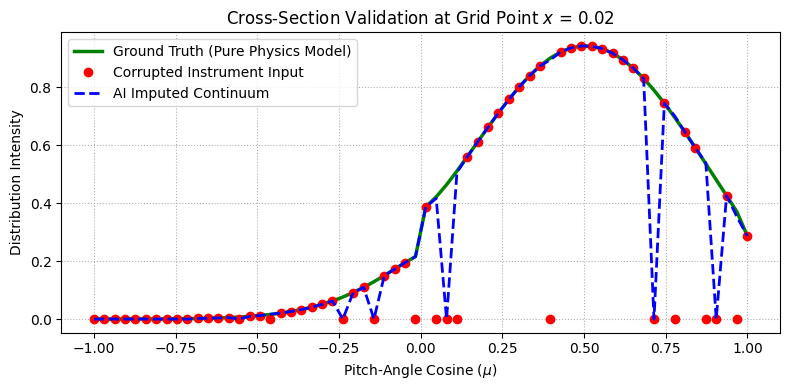

In [25]:
test_slice_idx = 50  # Mid-grid location near shock intersection zone

plt.figure(figsize=(8, 4), dpi=100)
plt.plot(mu_grid, f_evolved[test_slice_idx, :], 'g-', lw=2.5, label='Ground Truth (Pure Physics Model)')
plt.plot(mu_grid, f_corrupted[test_slice_idx, :], 'ro', markersize=6, label='Corrupted Instrument Input')
plt.plot(mu_grid, f_reconstructed[test_slice_idx, :], 'b--', lw=2, label='AI Imputed Continuum')
plt.xlabel("Pitch-Angle Cosine ($\mu$)")
plt.ylabel("Distribution Intensity")
plt.title(def_title := f"Cross-Section Validation at Grid Point $x$ = {x_grid[test_slice_idx]:.2f}")
plt.legend()
plt.grid(True, linestyle=':')
plt.tight_layout()
plt.show()

In [26]:
# Calculate Performance Metrics - ONLY on MISSING positions
missing_mask = ~observation_mask  # True where data is missing (False in degrader mask)

# Compute RMSE only where data was imputed
reconstruction_error = np.mean((f_evolved[missing_mask] - f_reconstructed[missing_mask]) ** 2)
print(f"\n>>> Computational pipeline execution verified successfully.")
print(f">>> Root Mean Squared Error (RMSE) across imputed positions: {np.sqrt(reconstruction_error):.5f}")

# Optional: Also show error on non-missing positions (should be near-zero)
available_mask = observation_mask  # True where data is available
error_available = np.mean((f_evolved[available_mask] - f_reconstructed[available_mask]) ** 2)
print(f">>> Error on available positions (should be near-zero): {np.sqrt(error_available):.5f}")


>>> Computational pipeline execution verified successfully.
>>> Root Mean Squared Error (RMSE) across imputed positions: 0.06197
>>> Error on available positions (should be near-zero): 0.00000
